<a href="https://colab.research.google.com/github/AngelJasmine24/Mtech-Final_Proj/blob/main/Byhis_grace.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
# =============================================
# Install Required Libraries
# =============================================

!pip install -q datasets
!pip install -q transformers
!pip install -q sentencepiece

!pip install -q tensorflow

!pip install -q scikit-learn

!pip install -q qiskit
!pip install -q qiskit-aer

!pip install -q wordcloud

In [1]:

# =============================================
# Imports
# =============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout,
    GlobalAveragePooling1D
)

from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

In [2]:
import tensorflow as tf
import qiskit

print("TensorFlow:", tf.__version__)
print("Qiskit:", qiskit.__version__)

TensorFlow: 2.20.0
Qiskit: 2.5.0


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import pandas as pd

sst2_train = pd.read_csv(
    "/content/drive/MyDrive/quantum sentence classification sst datasets/SST-2/train.tsv",
    sep="\t"
)

sst2_dev = pd.read_csv(
    "/content/drive/MyDrive/quantum sentence classification sst datasets/SST-2/dev.tsv",
    sep="\t"
)

In [5]:
sst2_train.head()

,sentence,label
0,hide new secretions from the parental units,0
1,"contains no wit , only labored gags",0
2,that loves its characters and communicates som...,1
3,remains utterly satisfied to remain the same t...,0
4,on the worst revenge-of-the-nerds clichés the ...,0


In [6]:
sst5_train = pd.read_csv(
    "/content/drive/MyDrive/quantum sentence classification sst datasets/SST-5/sst_train.tsv",
    sep="\t",
    header=None,
    names=["label", "text"]
)

sst5_dev = pd.read_csv(
    "/content/drive/MyDrive/quantum sentence classification sst datasets/SST-5/sst_dev.tsv",
    sep="\t",
    header=None,
    names=["label", "text"]
)

sst5_test = pd.read_csv(
    "/content/drive/MyDrive/quantum sentence classification sst datasets/SST-5/sst_test.tsv",
    sep="\t",
    header=None,
    names=["label", "text"]
)

In [7]:
sst5_train.head()

,label,text
0,__label__4,The Rock is destined to be the 21st Century 's...
1,__label__5,The gorgeously elaborate continuation of `` Th...
2,__label__4,Singer/composer Bryan Adams contributes a slew...
3,__label__3,You 'd think by now America would have had eno...
4,__label__4,Yet the act is still charming here .


In [8]:
print(sst2_train.shape)
print(sst5_train.shape)

(67349, 2)
(8544, 2)


In [9]:
label_map = {
    "__label__1": "negative",
    "__label__2": "negative",
    "__label__3": "neutral",
    "__label__4": "positive",
    "__label__5": "positive"
}

sst5_train["label"] = sst5_train["label"].map(label_map)
sst5_dev["label"] = sst5_dev["label"].map(label_map)
sst5_test["label"] = sst5_test["label"].map(label_map)

In [10]:
sst2_train["label"] = sst2_train["label"].map({
    0: "negative",
    1: "positive"
})

sst2_dev["label"] = sst2_dev["label"].map({
    0: "negative",
    1: "positive"
})

In [11]:
sst2_train = sst2_train.rename(
    columns={"sentence": "text"}
)

sst2_dev = sst2_dev.rename(
    columns={"sentence": "text"}
)

In [12]:
train_df = pd.concat([
    sst2_train,
    sst5_train
], ignore_index=True)

test_df = pd.concat([
    sst2_dev,
    sst5_test
], ignore_index=True)

In [13]:
print(train_df.head())
print(train_df.label.value_counts())
print(test_df["label"].value_counts())
print(train_df.shape)
print(test_df.shape)

                                                text     label
0       hide new secretions from the parental units   negative
1               contains no wit , only labored gags   negative
2  that loves its characters and communicates som...  positive
3  remains utterly satisfied to remain the same t...  negative
4  on the worst revenge-of-the-nerds clichés the ...  negative
label
positive    41179
negative    33090
neutral      1624
Name: count, dtype: int64
label
positive    1353
negative    1340
neutral      389
Name: count, dtype: int64
(75893, 2)
(3082, 2)


In [14]:
import random
neutral = train_df[train_df.label == "neutral"]

def augment(text):
    words = text.split()

    if len(words) > 4:
        i = random.randint(0, len(words)-1)
        words[i] = words[random.randint(0, len(words)-1)]

    return " ".join(words)
target = 8000

copies = target // len(neutral)

print(copies)
# create MANY augmented copies
augmented_rows = []

for _ in range(copies):   # increase neutral 4x
    temp = neutral.copy()
    temp["text"] = temp["text"].apply(augment)
    augmented_rows.append(temp)

neutral_aug = pd.concat(augmented_rows)

train_df = pd.concat([train_df, neutral_aug])

train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(train_df["label"].value_counts())

4
label
positive    41179
negative    33090
neutral      8120
Name: count, dtype: int64


In [21]:
le = LabelEncoder()

train_labels = le.fit_transform(train_df["label"])
test_labels  = le.transform(test_df["label"])
tokenizer = Tokenizer(num_words=12000)
tokenizer.fit_on_texts(train_df["text"])

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(train_df["text"]), maxlen=120)
X_test_seq  = pad_sequences(tokenizer.texts_to_sequences(test_df["text"]), maxlen=120)

In [22]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)
lstm_model = Sequential([
    Embedding(12000, 128, input_length=120),
    LSTM(64, return_sequences=True),
    GlobalAveragePooling1D(),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')
])

lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
history = lstm_model.fit(
    X_train_seq,
    train_labels,
    validation_split=0.1,
    epochs=20,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


2318/2318 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - accuracy: 0.7056 - loss: 0.6606 - val_accuracy: 0.8327 - val_loss: 0.4429
Epoch 2/20
2318/2318 ━━━━━━━━━━━━━━━━━━━━ 25s 11ms/step - accuracy: 0.8855 - loss: 0.3197 - val_accuracy: 0.8881 - val_loss: 0.3015
Epoch 3/20
2318/2318 ━━━━━━━━━━━━━━━━━━━━ 25s 11ms/step - accuracy: 0.9281 - loss: 0.2032 - val_accuracy: 0.9136 - val_loss: 0.2454
Epoch 4/20
2318/2318 ━━━━━━━━━━━━━━━━━━━━ 26s 11ms/step - accuracy: 0.9482 - loss: 0.1462 - val_accuracy: 0.9213 - val_loss: 0.2278
Epoch 5/20
2318/2318 ━━━━━━━━━━━━━━━━━━━━ 27s 12ms/step - accuracy: 0.9606 - loss: 0.1095 - val_accuracy: 0.9263 - val_loss: 0.2287
Epoch 6/20
2318/2318 ━━━━━━━━━━━━━━━━━━━━ 25s 11ms/step - accuracy: 0.9690 - loss: 0.0849 - val_accuracy: 0.9285 - val_loss: 0.2329
Epoch 7/20
2318/2318 ━━━━━━━━━━━━━━━━━━━━ 26s 11ms/step - accuracy: 0.9745 - loss: 0.0682 - val_accuracy: 0.9307 - val_loss: 0.2448


In [23]:
pred = np.argmax(lstm_model.predict(X_test_seq), axis=1)

from sklearn.metrics import classification_report

print(classification_report(test_labels, pred, target_names=le.classes_))

97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
              precision    recall  f1-score   support

    negative       0.73      0.66      0.69      1340
     neutral       0.18      0.28      0.22       389
    positive       0.74      0.70      0.72      1353

    accuracy                           0.63      3082
   macro avg       0.55      0.54      0.54      3082
weighted avg       0.66      0.63      0.64      3082



LSTM BASELINE RESULTS

Accuracy : 0.6265

Classification Report

              precision    recall  f1-score   support

    negative     0.7264    0.6560    0.6894      1340
     neutral     0.1780    0.2751    0.2162       389
    positive     0.7435    0.6984    0.7203      1353

    accuracy                         0.6265      3082
   macro avg     0.5493    0.5432    0.5419      3082
weighted avg     0.6647    0.6265    0.6432      3082



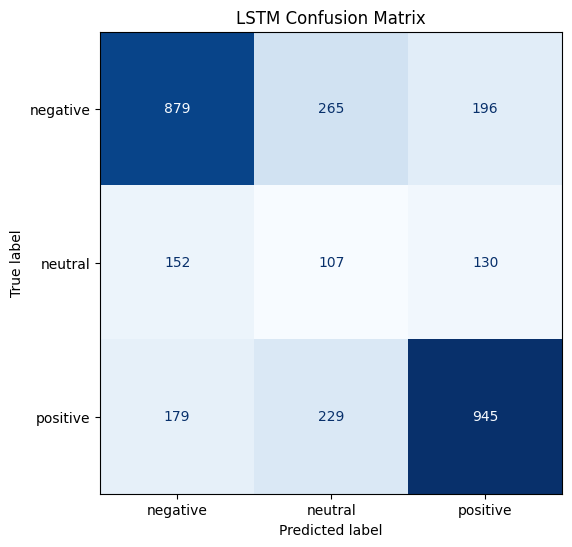

In [24]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score
)

import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# LSTM BASELINE EVALUATION
# ==========================================

#subset = test_df.iloc[:1000]
subset = test_df
X_test_lstm = pad_sequences(
    tokenizer.texts_to_sequences(subset["text"]),
    maxlen=120
)

lstm_probs = lstm_model.predict(
    X_test_lstm,
    verbose=0
)

lstm_pred = le.inverse_transform(
    np.argmax(lstm_probs, axis=1)
    )

true = subset["label"]

print("="*60)
print("LSTM BASELINE RESULTS")
print("="*60)

print("\nAccuracy :", round(accuracy_score(true, lstm_pred),4))

print("\nClassification Report\n")

print(
    classification_report(
        true,
        lstm_pred,
        digits=4
    )
)

cm = confusion_matrix(
    true,
    lstm_pred,
    labels=["negative","neutral","positive"]
)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["negative","neutral","positive"]
)

fig, ax = plt.subplots(figsize=(6,6))

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False
)

plt.title("LSTM Confusion Matrix")

plt.show()

In [25]:
# ============================
# TF-IDF + Feedforward Neural Network
# ============================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from scipy.sparse import csr_matrix

tfidf = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1,3)
)

X_train_tfidf = tfidf.fit_transform(train_df["text"])
X_test_tfidf  = tfidf.transform(test_df["text"])

# Convert sparse matrix to dense
X_train_dense = X_train_tfidf.toarray()
X_test_dense  = X_test_tfidf.toarray()

fnn_model = Sequential([
    Dense(512, activation="relu", input_shape=(8000,)),
    Dropout(0.3),

    Dense(256, activation="relu"),
    Dropout(0.3),

    Dense(64, activation="relu"),

    Dense(3, activation="softmax")
])

fnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_fnn = fnn_model.fit(
    X_train_dense,
    train_labels,
    validation_data=(X_test_dense, test_labels),
    epochs=10,
    batch_size=32,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
2575/2575 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - accuracy: 0.8124 - loss: 0.4520 - val_accuracy: 0.6603 - val_loss: 1.0187
Epoch 2/10
2575/2575 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9153 - loss: 0.2004 - val_accuracy: 0.6285 - val_loss: 1.4841
Epoch 3/10
2575/2575 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9346 - loss: 0.1468 - val_accuracy: 0.6431 - val_loss: 1.9139
Epoch 4/10
2575/2575 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9439 - loss: 0.1196 - val_accuracy: 0.6609 - val_loss: 1.9760
Epoch 5/10
2575/2575 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9505 - loss: 0.1029 - val_accuracy: 0.6509 - val_loss: 2.2665
Epoch 6/10
2575/2575 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9535 - loss: 0.0937 - val_accuracy: 0.6567 - val_loss: 2.1562
Epoch 7/10
2575/2575 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9560 - loss: 0.0868 - val_accuracy: 0.6746 - val_loss: 2.4824
Epoch 8/10
2575/2575 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9582 - loss: 0.

FNN BASELINE RESULTS

Accuracy : 0.6515

Classification Report

              precision    recall  f1-score   support

    negative     0.7431    0.6433    0.6896      1340
     neutral     0.1709    0.1748    0.1728       389
    positive     0.7073    0.7967    0.7494      1353

    accuracy                         0.6515      3082
   macro avg     0.5404    0.5383    0.5373      3082
weighted avg     0.6552    0.6515    0.6506      3082



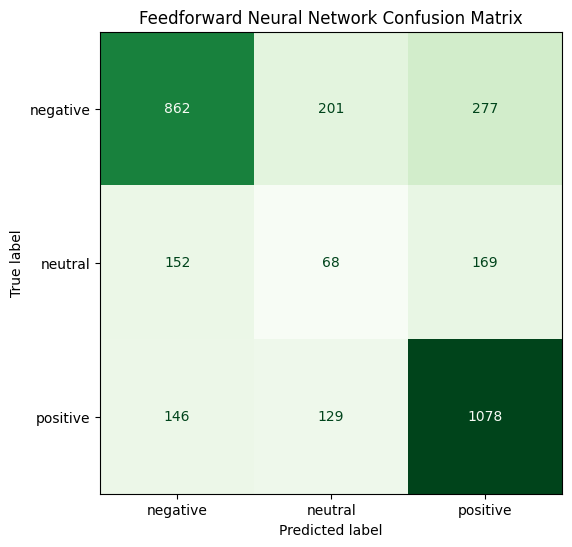

In [27]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score
)

subset = test_df

X_test_fnn = tfidf.transform(
    subset["text"]
).toarray()

fnn_probs = fnn_model.predict(
    X_test_fnn,
    verbose=0
)

fnn_pred = le.inverse_transform(
    np.argmax(fnn_probs, axis=1)
)

true = subset["label"]

print("="*60)
print("FNN BASELINE RESULTS")
print("="*60)
print("\nAccuracy :", round(accuracy_score(true, fnn_pred),4))
print("\nClassification Report\n")

print(
    classification_report(
        true,
        fnn_pred,
        digits=4
    )
)

cm = confusion_matrix(
    true,
    fnn_pred,
    labels=["negative","neutral","positive"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["negative","neutral","positive"]
)

fig, ax = plt.subplots(figsize=(6,6))

disp.plot(
    cmap="Greens",
    ax=ax,
    colorbar=False
)
plt.title("Feedforward Neural Network Confusion Matrix")

plt.show()

In [29]:
import tensorflow as tf
import qiskit

print("TensorFlow:", tf.__version__)
print("Qiskit:", qiskit.__version__)

TensorFlow: 2.20.0
Qiskit: 2.5.0


In [30]:
def quantum_circuit(features):

    qc = QuantumCircuit(8)

    # Layer 1
    for i in range(8):
        qc.ry(np.pi * features[i], i)

    # Entanglement
    for i in range(7):
        qc.cx(i, i + 1)

    # Layer 2
    for i in range(8):
        qc.rz(np.pi * features[i], i)
        qc.rx(np.pi * features[i] / 2, i)

    # Second Entanglement
    for i in range(7):
        qc.cz(i, i + 1)

    return qc

In [35]:
# ==========================================
# Quantum Feature Extraction
# ==========================================

from qiskit.quantum_info import SparsePauliOp

def quantum_features(features):

    qc = quantum_circuit(features)

    state = Statevector.from_instruction(qc)

    q_features = []

    for qubit in range(8):

        observable = SparsePauliOp.from_list(
            [("I"*qubit + "Z" + "I"*(7-qubit), 1)]
        )

        expectation = np.real(
            state.expectation_value(observable)
        )

        q_features.append(expectation)

    return np.array(q_features)

In [32]:
# ==========================================
# TF-IDF Vectorization
# ==========================================

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X_train_tfidf = tfidf.fit_transform(train_df["text"])

X_test_tfidf = tfidf.transform(test_df["text"])

print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(82389, 5000)
(3082, 5000)


In [33]:
# ==========================================
# Semantic Compression
# ==========================================

from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(
    n_components=8,
    random_state=42
)

train_quantum_input = svd.fit_transform(
    X_train_tfidf
)

test_quantum_input = svd.transform(
    X_test_tfidf
)

print(train_quantum_input.shape)

(82389, 8)


In [36]:
train_quantum = np.array([
    quantum_features(x)
    for x in train_quantum_input
])

test_quantum = np.array([
    quantum_features(x)
    for x in test_quantum_input
])

print(train_quantum.shape)
print(test_quantum.shape)

(82389, 8)
(3082, 8)


In [37]:
from tensorflow.keras.models import Model

# Make sure the model is built
_ = lstm_model.predict(X_train_seq[:1], verbose=0)

lstm_feature_model = Model(
    inputs=lstm_model.inputs,
    outputs=lstm_model.layers[-2].output
)

lstm_train_feat = lstm_feature_model.predict(
    X_train_seq,
    batch_size=256,
    verbose=1
)

lstm_test_feat = lstm_feature_model.predict(
    X_test_seq,
    batch_size=256,
    verbose=1
)

print(lstm_train_feat.shape)
print(lstm_test_feat.shape)

322/322 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
(82389, 64)
(3082, 64)


In [38]:
from tensorflow.keras.models import Model

# Build model if needed
_ = fnn_model.predict(X_train_dense[:1], verbose=0)

fnn_feature_model = Model(
    inputs=fnn_model.inputs,
    outputs=fnn_model.layers[-2].output
)

fnn_train_feat = fnn_feature_model.predict(
    X_train_dense,
    batch_size=256,
    verbose=1
)

fnn_test_feat = fnn_feature_model.predict(
    X_test_dense,
    batch_size=256,
    verbose=1
)

print(fnn_train_feat.shape)
print(fnn_test_feat.shape)

322/322 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
(82389, 64)
(3082, 64)


In [39]:
from sklearn.preprocessing import StandardScaler

lstm_scaler = StandardScaler()
fnn_scaler = StandardScaler()
quantum_scaler = StandardScaler()

lstm_train_feat = lstm_scaler.fit_transform(lstm_train_feat)
lstm_test_feat = lstm_scaler.transform(lstm_test_feat)

fnn_train_feat = fnn_scaler.fit_transform(fnn_train_feat)
fnn_test_feat = fnn_scaler.transform(fnn_test_feat)

train_quantum = quantum_scaler.fit_transform(train_quantum)
test_quantum = quantum_scaler.transform(test_quantum)

In [40]:
import numpy as np

fusion_train_X = np.concatenate(
    (
        lstm_train_feat,
        fnn_train_feat,
        train_quantum
    ),
    axis=1
)

fusion_test_X = np.concatenate(
    (
        lstm_test_feat,
        fnn_test_feat,
        test_quantum
    ),
    axis=1
)

print(fusion_train_X.shape)
print(fusion_test_X.shape)

(82389, 136)
(3082, 136)


In [41]:
from sklearn.neural_network import MLPClassifier

fusion_model = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64),
    activation="relu",
    solver="adam",
    alpha=0.0005,
    learning_rate_init=0.0005,
    batch_size=64,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)

fusion_model.fit(fusion_train_X, train_labels)

MLPClassifier(alpha=0.0005, batch_size=64, early_stopping=True,
              hidden_layer_sizes=(256, 128, 64), learning_rate_init=0.0005,
              max_iter=300, random_state=42)

In [42]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

fusion_pred = fusion_model.predict(fusion_test_X)

print("=" * 60)
print("HYBRID QUANTUM-CLASSICAL RESULTS")
print("=" * 60)

print("\nAccuracy :", round(
    accuracy_score(test_labels, fusion_pred), 4
))

print("\nClassification Report\n")
print(
    classification_report(
        test_labels,
        fusion_pred,
        target_names=le.classes_
    )
)

HYBRID QUANTUM-CLASSICAL RESULTS

Accuracy : 0.6665

Classification Report

              precision    recall  f1-score   support

    negative       0.75      0.70      0.72      1340
     neutral       0.17      0.18      0.18       389
    positive       0.74      0.77      0.75      1353

    accuracy                           0.67      3082
   macro avg       0.55      0.55      0.55      3082
weighted avg       0.67      0.67      0.67      3082



97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


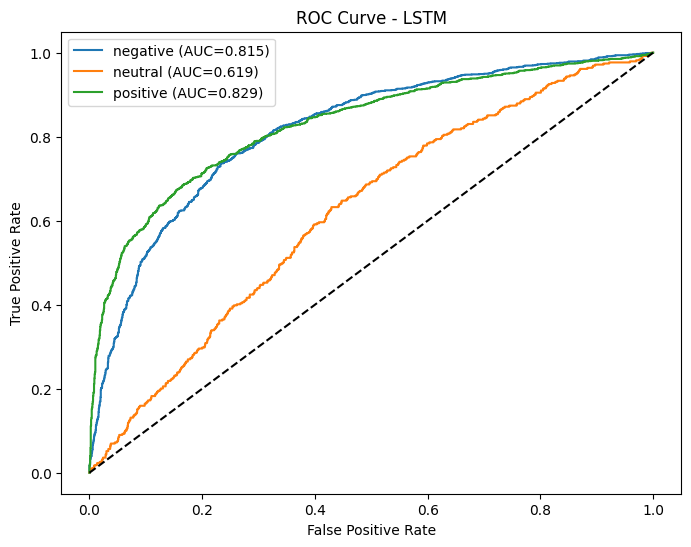

In [43]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_true = label_binarize(test_labels, classes=[0,1,2])

lstm_prob = lstm_model.predict(X_test_seq)

plt.figure(figsize=(8,6))

for i in range(3):

    fpr,tpr,_ = roc_curve(
        y_true[:,i],
        lstm_prob[:,i]
    )

    roc_auc = auc(fpr,tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{le.classes_[i]} (AUC={roc_auc:.3f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - LSTM")
plt.legend()

plt.savefig("roc_lstm.png",dpi=300)
plt.show()

97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


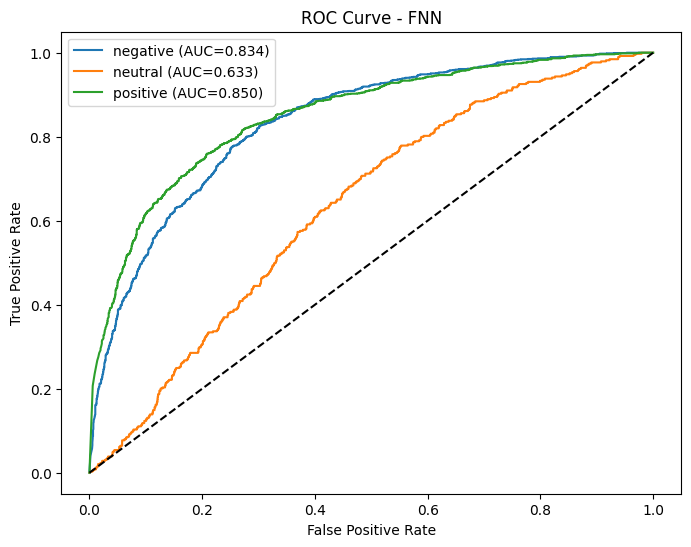

In [44]:
fnn_prob = fnn_model.predict(X_test_dense)

plt.figure(figsize=(8,6))

for i in range(3):

    fpr,tpr,_ = roc_curve(
        y_true[:,i],
        fnn_prob[:,i]
    )

    roc_auc = auc(fpr,tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{le.classes_[i]} (AUC={roc_auc:.3f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - FNN")
plt.legend()

plt.savefig("roc_fnn.png",dpi=300)
plt.show()

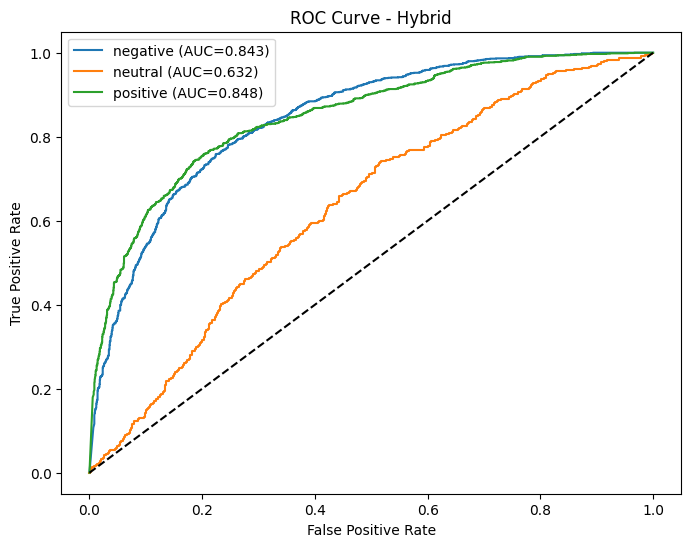

In [45]:
fusion_prob = fusion_model.predict_proba(fusion_test_X)

plt.figure(figsize=(8,6))

for i in range(3):

    fpr,tpr,_ = roc_curve(
        y_true[:,i],
        fusion_prob[:,i]
    )

    roc_auc = auc(fpr,tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{le.classes_[i]} (AUC={roc_auc:.3f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Hybrid")
plt.legend()

plt.savefig("roc_hybrid.png",dpi=300)
plt.show()

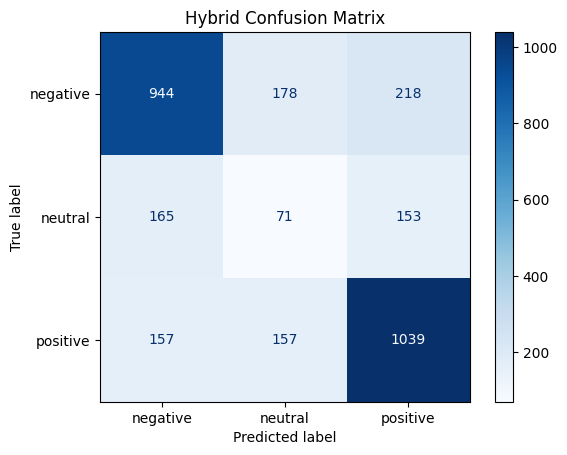

In [46]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    test_labels,
    fusion_pred,
    display_labels=le.classes_,
    cmap="Blues"
)

plt.title("Hybrid Confusion Matrix")

plt.savefig("confusion_hybrid.png",dpi=300)

plt.show()

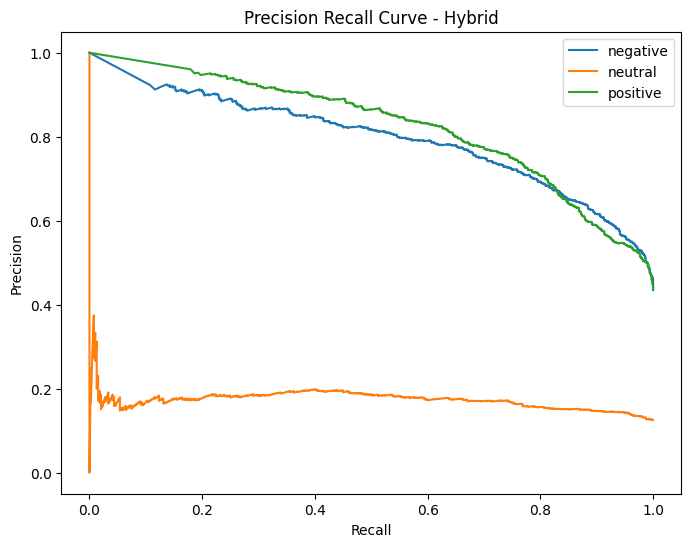

In [47]:
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(8,6))

for i in range(3):

    precision,recall,_ = precision_recall_curve(
        y_true[:,i],
        fusion_prob[:,i]
    )

    plt.plot(
        recall,
        precision,
        label=le.classes_[i]
    )

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision Recall Curve - Hybrid")

plt.legend()

plt.savefig("pr_curve_hybrid.png",dpi=300)

plt.show()

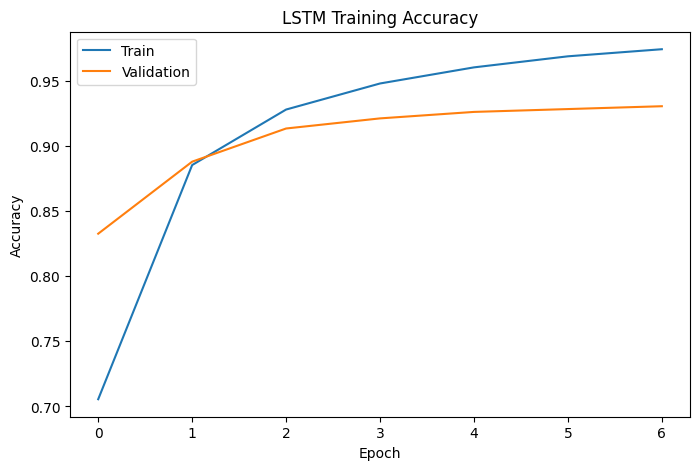

In [48]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"],label="Train")

plt.plot(history.history["val_accuracy"],label="Validation")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("LSTM Training Accuracy")

plt.legend()

plt.savefig("lstm_accuracy.png",dpi=300)

plt.show()

**not required for now**

# **old results**

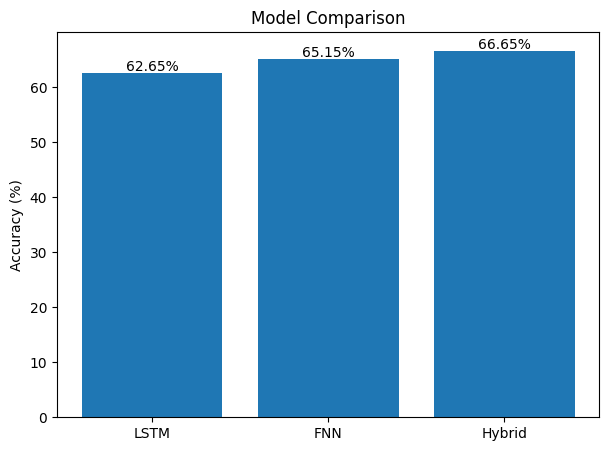

In [49]:
import matplotlib.pyplot as plt

models=[
    "LSTM",
    "FNN",
    "Hybrid"
]

accuracy=[
    62.65,
    65.15,
    66.65
]

plt.figure(figsize=(7,5))

bars=plt.bar(models,accuracy)

plt.ylabel("Accuracy (%)")

plt.title("Model Comparison")

for b,v in zip(bars,accuracy):

    plt.text(
        b.get_x()+b.get_width()/2,
        v+0.3,
        f"{v:.2f}%",
        ha="center"
    )

plt.savefig("comparison_bar.png",dpi=300)

plt.show()